# Darkness Final Synthesis

This notebook brings together the three analysis notebooks into one clear story:

- [Reprocess OR Confirmation.ipynb](./Reprocess%20OR%20Confirmation.ipynb): pooled case-control hour OR analysis
- [Darkness GLM Models.ipynb](./Darkness%20GLM%20Models.ipynb): main time-series GLM and heterogeneity analysis
- [Darkness OR And GLM Comparison.ipynb](./Darkness%20OR%20And%20GLM%20Comparison.ipynb): direct OR-versus-GLM comparison and mixed-hours robustness

## Question

**How does darkness affect pedestrian and cyclist counts in Bristol?**

## How to read this notebook

The notebook is built around one main comparison.

- The **OR analysis** shows the matched case-control hour pattern.
- The **6-hour GLM** is the main adjusted model because it uses the same mixed case hours as the OR analysis: `5, 6, 17, 18, 19, 20`.
- The **9-hour GLM** is used only as a short sensitivity check. It adds the other mixed hours `4, 7, 21` to test whether the main conclusions are stable.

The aim is not to repeat every intermediate step from the earlier notebooks. It is to show what the methods agree on, what the four GLM models add, and what this means for Bristol in practical terms.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ValueWarning
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ValueWarning)
plt.style.use('seaborn-v0_8-whitegrid')


def find_notebook_dir() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, cwd / 'main' / 'Karan - Notebooks and analysis']
    for candidate in candidates:
        if (candidate / 'Processed Data' / 'all_sensor_data_with_locations_and_clusters.csv').exists():
            return candidate
    for parent in [cwd, *cwd.parents]:
        candidate = parent / 'main' / 'Karan - Notebooks and analysis'
        if (candidate / 'Processed Data' / 'all_sensor_data_with_locations_and_clusters.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate the notebook data folder.')


NOTEBOOK_DIR = find_notebook_dir()
REPO_DIR = NOTEBOOK_DIR.parents[1]
PROCESSED_DATA_DIR = NOTEBOOK_DIR / 'Processed Data'

BASE_PANEL_PATH = PROCESSED_DATA_DIR / 'all_sensor_data_with_locations_and_clusters.csv'
WEATHER_PATH = REPO_DIR / 'data' / 'weather' / 'weather_2024_almondsbury_clean.csv'
RAIN_PATH = REPO_DIR / 'data' / 'weather' / 'rain_2024_almondsbury_clean.csv'
CCTV_PATH = PROCESSED_DATA_DIR / 'sensor_cctv_within_300m_clean37.csv'
SAFETY_PATH = PROCESSED_DATA_DIR / 'sensor_ward_safety_after_dark_2024_clean37.csv'
OR_LONG_PATH = PROCESSED_DATA_DIR / 'case_control_hour_or_pooled_ped_cyc_long.csv'

print('NOTEBOOK_DIR =', NOTEBOOK_DIR)
print('BASE_PANEL   =', BASE_PANEL_PATH)
print('OR_LONG      =', OR_LONG_PATH)


NOTEBOOK_DIR = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/main/Karan - Notebooks and analysis
BASE_PANEL   = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/main/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv
OR_LONG      = /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/main/Karan - Notebooks and analysis/Processed Data/case_control_hour_or_pooled_ped_cyc_long.csv


## Data And Methods At A Glance

All results below use the same cleaned **37-sensor** dataset created in the OR workflow.

### OR design
- Case hours: `5, 6, 17, 18, 19, 20`
- Dark control hours: `23, 0, 1, 2`
- Daylight control hours: `9, 10, 11, 12, 13, 14`
- Matching is done within `SensorNumber` and `day`

### Main GLM design
- Negative Binomial GLM with cluster-robust standard errors by sensor
- Controls include:
  - `C(hour)`, `C(dow)`, `C(month)`
  - `temp_c`, `wind_ms`, `rain_mm`
  - lagged counts (`lag1`, `lag24`)
  - `C(SensorNumber)` fixed effects

### What the four GLM models test
- **Model 1: Main pooled darkness model**
  - Tests the average darkness effect across all 37 sensors.
- **Model 2: Darkness by cluster**
  - Tests whether the darkness effect differs across `Central`, `East`, and `Outlier` sensors.
- **Model 3: Darkness by CCTV context**
  - Tests whether the darkness effect changes in places with more or less nearby CCTV.
- **Model 4: Darkness by safety context**
  - Tests whether the darkness effect changes with ward-level perceived after-dark safety.

The six-hour GLM is the main model because it is directly comparable to the OR design. The nine-hour GLM is only used to check whether the core results survive when more mixed-hour data are added.


In [2]:
# Load OR output
or_long = pd.read_csv(OR_LONG_PATH)
or_long['log_R_odds'] = np.log(or_long['R_odds'])
or_summary = (
    or_long.groupby(['Mode', 'case_hour', 'case_hour_label'], as_index=False)
    .agg(
        median_R_odds=('R_odds', 'median'),
        min_R_odds=('R_odds', 'min'),
        max_R_odds=('R_odds', 'max'),
        paired_rows=('paired_rows', 'first'),
        n_control_hours=('R_odds', 'size'),
    )
    .sort_values(['Mode', 'case_hour'])
    .reset_index(drop=True)
)

# Build panel for GLM summaries
panel = pd.read_csv(BASE_PANEL_PATH)
panel['datetime'] = pd.to_datetime(panel['date'], utc=True, errors='coerce')
weather = pd.read_csv(WEATHER_PATH)
weather['datetime'] = pd.to_datetime(weather['datetime'], utc=True, errors='coerce')
rain = pd.read_csv(RAIN_PATH)
rain['datetime'] = pd.to_datetime(rain['datetime'], utc=True, errors='coerce')
cctv = pd.read_csv(CCTV_PATH)[['SensorNumber', 'cctv_300m']].drop_duplicates('SensorNumber')
safety = pd.read_csv(SAFETY_PATH)[['SensorNumber', 'safety_after_dark_pct']].drop_duplicates('SensorNumber')

panel = panel.merge(weather, on='datetime', how='left')
panel = panel.merge(rain, on='datetime', how='left')
panel = panel.merge(cctv, on='SensorNumber', how='left')
panel = panel.merge(safety, on='SensorNumber', how='left')
panel['rain_mm'] = panel['rain_mm'].fillna(0)
panel['hour'] = panel['datetime'].dt.hour.astype(int)
panel['dow'] = panel['datetime'].dt.dayofweek.astype(int)
panel['month'] = panel['datetime'].dt.month.astype(int)
panel = panel.sort_values(['SensorNumber', 'datetime']).reset_index(drop=True)
panel['ped_lag1'] = panel.groupby('SensorNumber')['ped'].shift(1)
panel['ped_lag24'] = panel.groupby('SensorNumber')['ped'].shift(24)
panel['cyc_lag1'] = panel.groupby('SensorNumber')['cyc'].shift(1)
panel['cyc_lag24'] = panel.groupby('SensorNumber')['cyc'].shift(24)

comparison_hours = [5, 6, 17, 18, 19, 20]
expanded_hours = [4, 5, 6, 7, 17, 18, 19, 20, 21]


def coef_percent_change(beta):
    return 100 * (np.exp(beta) - 1)


def fit_nb_glm(data, outcome, rhs, required_cols, label):
    cols = list(dict.fromkeys(required_cols + [outcome, 'SensorNumber']))
    model_df = data[cols].dropna().copy()
    formula = f'{outcome} ~ {rhs}'
    model = smf.glm(formula=formula, data=model_df, family=sm.families.NegativeBinomial())
    result = model.fit(cov_type='cluster', cov_kwds={'groups': model_df['SensorNumber']})
    info = {
        'label': label,
        'outcome': outcome,
        'n_rows': len(model_df),
        'n_sensors': model_df['SensorNumber'].nunique(),
        'dispersion': float((result.pearson_chi2 / result.df_resid) if result.df_resid else np.nan),
        'formula': formula,
    }
    return result, model_df, info


def run_model_ladder(panel_df, sample_name):
    sensor_context = (
        panel_df[['SensorNumber', 'Cluster', 'cctv_300m', 'safety_after_dark_pct']]
        .drop_duplicates('SensorNumber')
        .sort_values('SensorNumber')
        .reset_index(drop=True)
    )
    analysis_df = panel_df.copy()
    analysis_df['Cluster'] = pd.Categorical(analysis_df['Cluster'], categories=['Central', 'East', 'Outlier'])
    analysis_df['cctv_z'] = (analysis_df['cctv_300m'] - sensor_context['cctv_300m'].mean()) / sensor_context['cctv_300m'].std()
    analysis_df['safety_z'] = (analysis_df['safety_after_dark_pct'] - sensor_context['safety_after_dark_pct'].mean()) / sensor_context['safety_after_dark_pct'].std()

    model_specs = {
        'Model 1': {
            'ped': {
                'rhs': 'Dark + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
            'cyc': {
                'rhs': 'Dark + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
        },
        'Model 2': {
            'ped': {
                'rhs': "Dark + Dark:C(Cluster, Treatment(reference='Central')) + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)",
                'required_cols': ['Dark', 'Cluster', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
            'cyc': {
                'rhs': "Dark + Dark:C(Cluster, Treatment(reference='Central')) + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)",
                'required_cols': ['Dark', 'Cluster', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
        },
        'Model 3': {
            'ped': {
                'rhs': 'Dark + Dark:cctv_z + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'cctv_z', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
            'cyc': {
                'rhs': 'Dark + Dark:cctv_z + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'cctv_z', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
        },
        'Model 4': {
            'ped': {
                'rhs': 'Dark + Dark:safety_z + ped_lag1 + ped_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'safety_z', 'ped_lag1', 'ped_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
            'cyc': {
                'rhs': 'Dark + Dark:safety_z + cyc_lag1 + cyc_lag24 + C(hour) + C(dow) + C(month) + temp_c + wind_ms + rain_mm + C(SensorNumber)',
                'required_cols': ['Dark', 'safety_z', 'cyc_lag1', 'cyc_lag24', 'hour', 'dow', 'month', 'temp_c', 'wind_ms', 'rain_mm', 'SensorNumber'],
            },
        },
    }

    model_results = {}
    summary_rows = []
    for model_name, spec in model_specs.items():
        for outcome, outcome_spec in spec.items():
            result, model_df, info = fit_nb_glm(
                analysis_df,
                outcome=outcome,
                rhs=outcome_spec['rhs'],
                required_cols=outcome_spec['required_cols'],
                label=f'{sample_name} | {model_name}',
            )
            model_results[(model_name, outcome)] = {'result': result, 'data': model_df, 'info': info}
            summary_rows.append({
                'sample': sample_name,
                'model': model_name,
                'outcome': outcome,
                'n_rows': info['n_rows'],
                'n_sensors': info['n_sensors'],
                'dispersion': info['dispersion'],
                'dark_coef': result.params['Dark'],
                'dark_percent_change': coef_percent_change(result.params['Dark']),
                'dark_p_value': result.pvalues['Dark'],
                'comparable_pooled_dark_effect': model_name in {'Model 1', 'Model 3', 'Model 4'},
            })
    return analysis_df, model_results, pd.DataFrame(summary_rows)


comparison_df = panel.loc[panel['light_class'].isin(['daylight', 'darkness']) & panel['hour'].isin(comparison_hours)].copy()
expanded_df = panel.loc[panel['light_class'].isin(['daylight', 'darkness']) & panel['hour'].isin(expanded_hours)].copy()

comparison_analysis_df, comparison_results, comparison_summary = run_model_ladder(comparison_df, 'Comparison GLM (6 mixed hours)')
expanded_analysis_df, expanded_results, expanded_summary = run_model_ladder(expanded_df, 'Expanded GLM (9 mixed hours)')

# Raw mixed-hour summaries on the 6-hour comparison sample
raw_compare = comparison_df.groupby('light_class')[['ped', 'cyc']].mean().round(3)

sensor_level = comparison_df.groupby(['SensorNumber', 'Cluster', 'light_class'])[['ped', 'cyc']].mean().unstack('light_class')
sensor_level.columns = [f'{a}_{b}' for a, b in sensor_level.columns]
sensor_level = sensor_level.dropna().reset_index()
for mode in ['ped', 'cyc']:
    sensor_level[f'{mode}_pct'] = (sensor_level[f'{mode}_darkness'] / sensor_level[f'{mode}_daylight'] - 1) * 100
sensor_sign_counts = sensor_level.groupby('Cluster').agg(
    ped_drop=('ped_pct', lambda s: int((s < 0).sum())),
    cyc_drop=('cyc_pct', lambda s: int((s < 0).sum())),
    cyc_increase=('cyc_pct', lambda s: int((s > 0).sum())),
    n=('SensorNumber', 'count'),
)

# Cyclist heterogeneity summaries from the 6-hour sample

def linear_combo_summary(result, weights):
    params = result.params
    cov = result.cov_params()
    idx = list(params.index)
    w = np.zeros(len(idx))
    for name, value in weights.items():
        if name in idx:
            w[idx.index(name)] = value
    est = float(np.dot(w, params.values))
    var = float(w @ cov.values @ w)
    se = float(np.sqrt(max(var, 0)))
    lo = est - 1.96 * se
    hi = est + 1.96 * se
    return {'coef': est, 'pct': coef_percent_change(est), 'lo_pct': coef_percent_change(lo), 'hi_pct': coef_percent_change(hi)}


def get_cluster_term(result, label):
    for name in result.params.index:
        if 'Dark:C(Cluster' in name and label in name:
            return name
    return None

cluster_res = comparison_results[('Model 2', 'cyc')]['result']
cyclist_cluster_effects = []
for cluster_name in ['Central', 'East', 'Outlier']:
    weights = {'Dark': 1.0}
    if cluster_name == 'East':
        weights[get_cluster_term(cluster_res, 'East')] = 1.0
    elif cluster_name == 'Outlier':
        weights[get_cluster_term(cluster_res, 'Outlier')] = 1.0
    cyclist_cluster_effects.append({'cluster': cluster_name, **linear_combo_summary(cluster_res, weights)})
cyclist_cluster_effects = pd.DataFrame(cyclist_cluster_effects)

safety_res = comparison_results[('Model 4', 'cyc')]['result']
cyclist_safety_effects = []
for x, label in [(-1.0, 'Low (-1 SD)'), (0.0, 'Average'), (1.0, 'High (+1 SD)')]:
    cyclist_safety_effects.append({'level': label, **linear_combo_summary(safety_res, {'Dark': 1.0, 'Dark:safety_z': x})})
cyclist_safety_effects = pd.DataFrame(cyclist_safety_effects)

# concise evidence table
main_glm_compare = pd.concat([comparison_summary, expanded_summary], ignore_index=True)
main_glm_compare = main_glm_compare.loc[main_glm_compare['comparable_pooled_dark_effect']].copy()
main_glm_compare['outcome_label'] = main_glm_compare['outcome'].map({'ped': 'Pedestrians', 'cyc': 'Cyclists'})

key_metrics = pd.DataFrame([
    {'Evidence': 'OR median at 06:00', 'Pedestrians': '3.06', 'Cyclists': '2.21', 'Meaning': 'Strongest OR contrast is in the morning, stronger for pedestrians.'},
    {'Evidence': 'Comparison GLM Model 1', 'Pedestrians': '-33.3% (p=1.48e-09)', 'Cyclists': '-4.0% (p=0.446)', 'Meaning': 'Main pooled GLM result on the OR-matched hour set.'},
    {'Evidence': 'Expanded GLM Model 1', 'Pedestrians': '-37.0% (p=2.57e-10)', 'Cyclists': '-4.4% (p=0.395)', 'Meaning': 'Adding all mixed hours strengthens walking and leaves cycling broadly unchanged.'},
    {'Evidence': 'Raw 6-hour means', 'Pedestrians': '116.9 daylight vs 62.3 darkness', 'Cyclists': '27.2 daylight vs 17.6 darkness', 'Meaning': 'Both modes fall raw, but only walking retains a strong pooled effect after controls.'},
    {'Evidence': 'Sensor-level spread', 'Pedestrians': '36 of 37 sensors drop', 'Cyclists': '10 of 37 sensors increase', 'Meaning': 'Walking is widespread and consistent; cycling is more mixed.'},
    {'Evidence': 'Cyclist Model 2 cluster effects', 'Pedestrians': 'Walking not emphasised here', 'Cyclists': 'Central -20.5%, East -1.6%, Outlier +20.4%', 'Meaning': 'Cyclist darkness response varies strongly by place.'},
    {'Evidence': 'Cyclist Model 4 safety interaction', 'Pedestrians': 'Pedestrian interaction weak', 'Cyclists': 'Dark:safety_z p=0.000121', 'Meaning': 'Cyclist darkness response changes with broader place context.'},
    {'Evidence': 'CCTV interaction', 'Pedestrians': 'p=0.948', 'Cyclists': 'p=0.941', 'Meaning': 'CCTV does not explain the darkness effect in these models.'},
])

display(key_metrics)
print('Raw comparison-sample means:')
display(raw_compare)
print('Sensor-level sign counts by cluster:')
display(sensor_sign_counts)


,Evidence,Pedestrians,Cyclists,Meaning
0,OR median at 06:00,3.06,2.21,"Strongest OR contrast is in the morning, stron..."
1,Comparison GLM Model 1,-33.3% (p=1.48e-09),-4.0% (p=0.446),Main pooled GLM result on the OR-matched hour ...
2,Expanded GLM Model 1,-37.0% (p=2.57e-10),-4.4% (p=0.395),Adding all mixed hours strengthens walking and...
3,Raw 6-hour means,116.9 daylight vs 62.3 darkness,27.2 daylight vs 17.6 darkness,"Both modes fall raw, but only walking retains ..."
4,Sensor-level spread,36 of 37 sensors drop,10 of 37 sensors increase,Walking is widespread and consistent; cycling ...
5,Cyclist Model 2 cluster effects,Walking not emphasised here,"Central -20.5%, East -1.6%, Outlier +20.4%",Cyclist darkness response varies strongly by p...
6,Cyclist Model 4 safety interaction,Pedestrian interaction weak,Dark:safety_z p=0.000121,Cyclist darkness response changes with broader...
7,CCTV interaction,p=0.948,p=0.941,CCTV does not explain the darkness effect in t...


Raw comparison-sample means:


,ped,cyc
light_class,,
darkness,62.310,17.589
daylight,116.918,27.231


Sensor-level sign counts by cluster:


,ped_drop,cyc_drop,cyc_increase,n
Cluster,,,,
Central,9,8,1,9
East,19,15,5,20
Outlier,8,4,4,8


## Key Metrics At A Glance

The table above gives the short version of the evidence base.

The main message is already visible:

- **Pedestrians show a strong and consistent darkness effect across methods.**
  - OR medians are above `1` at every case hour.
  - The main six-hour GLM gives about `-33.3%` with `p = 1.48e-09`.
  - The nine-hour sensitivity check gives about `-37.0%` with `p = 2.57e-10`.
- **Cyclists show a weaker pooled city-wide effect and a stronger heterogeneity story.**
  - The pooled six-hour GLM gives about `-4.0%` with `p = 0.446`.
  - The nine-hour sensitivity check is still about `-4.4%` with `p = 0.395`.
  - The more informative cyclist results appear when place type and place context are introduced.

So the OR and GLM results are not pulling in different directions. They are building a fuller version of the same overall picture.


## Figure 1: OR Evidence

Figure 1 is the starting point because it is closest to the original case-control hour design.

For each case hour, it compares the daylight and darkness versions of that hour against fixed daylight and dark control hours. The OR should therefore be read as a **matched contrast**, not as a percent change in counts.

The most important things to look for are:
- whether the OR is above `1`
- whether that pattern is stronger for one mode than the other
- whether the same hours stand out repeatedly


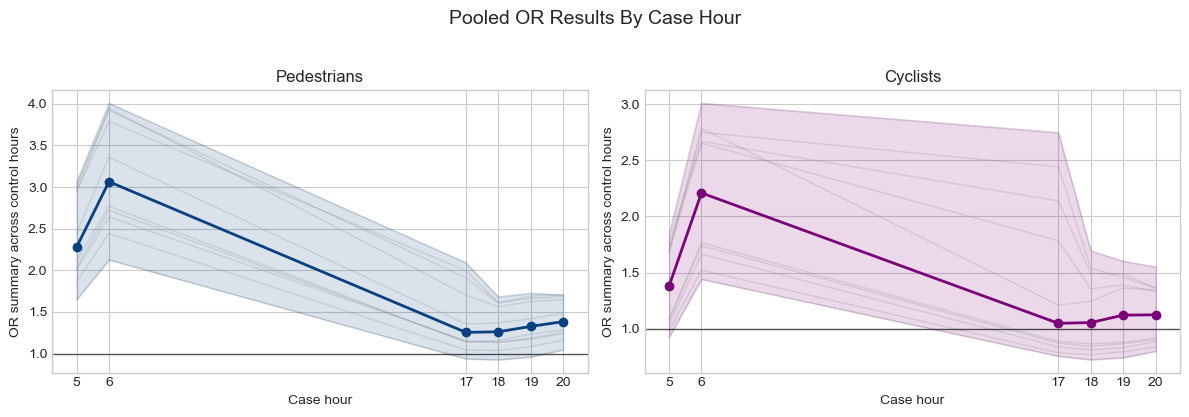

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
mode_order = ['Pedestrians', 'Cyclists']
colors = {'Pedestrians': '#084081', 'Cyclists': '#7a0177'}

for ax, mode_name in zip(axes, mode_order):
    sub = or_long[or_long['Mode'] == mode_name].copy()
    summ = or_summary[or_summary['Mode'] == mode_name].copy()

    for _, control_group in sub.groupby('control_hour_label'):
        ax.plot(control_group['case_hour'], control_group['R_odds'], color='grey', alpha=0.22, linewidth=1)
    ax.plot(summ['case_hour'], summ['median_R_odds'], marker='o', color=colors[mode_name], linewidth=2)
    ax.fill_between(summ['case_hour'], summ['min_R_odds'], summ['max_R_odds'], color=colors[mode_name], alpha=0.15)
    ax.axhline(1.0, color='black', linewidth=1, alpha=0.6)
    ax.set_xticks(sorted(summ['case_hour'].unique()))
    ax.set_title(mode_name)
    ax.set_xlabel('Case hour')
    ax.set_ylabel('OR summary across control hours')

fig.suptitle('Pooled OR Results By Case Hour', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


### What Figure 1 Means

Figure 1 already establishes the main cross-method pattern.

- **Pedestrians have the clearer OR signal.** Median pedestrian ORs are above `1` at every case hour and are especially large at `05:00` (`2.28`) and `06:00` (`3.06`).
- **Cyclists also show a morning signal, but it is weaker and less stable.** The cyclist median OR is strongest at `06:00` (`2.21`), moderate at `05:00` (`1.38`), and much closer to `1` in the evening (`17:00` to `20:00`).
- **The strongest contrast appears when darkness overlaps with regular morning travel.** That matters because it suggests the question is not just about late-night activity. It is about whether people travel differently when ordinary daily trips happen in darkness.

The grey lines show that the exact OR changes with the choice of control hour. That is why the GLM matters. The GLM uses the same cleaned sensors and the same mixed case hours, but controls directly for hour, day, month, weather, short-run persistence, and fixed sensor differences.


## Figure 2: OR-Comparable GLM And Sensitivity Check

Figure 2 keeps the GLM evidence focused.

- The **blue line** is the main six-hour GLM, fitted on the same mixed case hours as the OR design: `5, 6, 17, 18, 19, 20`.
- The **purple line** is the nine-hour sensitivity check, which adds the other mixed hours `4`, `7`, and `21`.

Only **Models 1, 3, and 4** are shown here because their `Dark` coefficients are pooled city-wide effects. Model 2 is excluded from this figure because its `Dark` term is the reference-cluster effect, not a city-wide average.


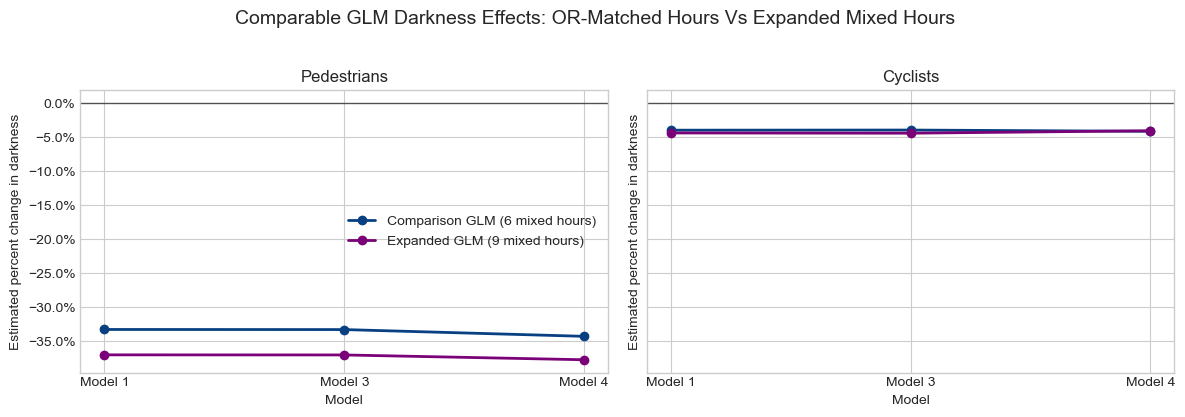

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
model_order = ['Model 1', 'Model 3', 'Model 4']
sample_order = ['Comparison GLM (6 mixed hours)', 'Expanded GLM (9 mixed hours)']
colors = {
    'Comparison GLM (6 mixed hours)': '#084081',
    'Expanded GLM (9 mixed hours)': '#7a0177',
}

for ax, outcome_label in zip(axes, ['Pedestrians', 'Cyclists']):
    sub = main_glm_compare[main_glm_compare['outcome_label'] == outcome_label].copy()
    ax.axhline(0, color='black', linewidth=1, alpha=0.6)
    for sample_name in sample_order:
        sample_sub = sub[sub['sample'] == sample_name].copy()
        sample_sub['x'] = [model_order.index(m) for m in sample_sub['model']]
        ax.plot(sample_sub['x'], sample_sub['dark_percent_change'], marker='o', linewidth=2, color=colors[sample_name], label=sample_name)
    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_title(outcome_label)
    ax.set_xlabel('Model')
    ax.set_ylabel('Estimated percent change in darkness')

axes[0].legend(loc='best')
fig.suptitle('Comparable GLM Darkness Effects: OR-Matched Hours Vs Expanded Mixed Hours', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


### What Figure 2 Means

Figure 2 shows the clearest OR-versus-GLM takeaway.

- **Walking stays strongly negative in every pooled GLM.**
  - Six-hour sample: around `-33%` to `-34%`
  - Nine-hour sensitivity check: around `-37%` to `-38%`
- **Cycling stays close to zero in every pooled GLM.**
  - Six-hour sample: around `-4%`
  - Nine-hour sensitivity check: also around `-4%`

This matters for two reasons.

First, the pedestrian darkness effect survives adjustment. The OR says the matched daylight-dark contrast is strong, and the GLM says that the result remains strong after controlling for time structure, weather, autocorrelation, and fixed sensor differences.

Second, the nine-hour GLM does not change the story. It makes the pedestrian result slightly stronger and leaves the cyclist pooled result essentially unchanged. That is why the six-hour GLM remains the main model and the nine-hour GLM is best treated as a sensitivity check rather than a second competing analysis.


## Figure 3: What The Four GLM Models Add

The OR analysis tells us whether the matched dark-light contrast is present. The four GLM models tell us what happens once we move to an adjusted count model and start asking more specific questions.

Figure 3 focuses on the part of the GLM evidence that adds the most extra value: why the pooled cyclist effect stays weak even though the raw data do show some darkness-related change.


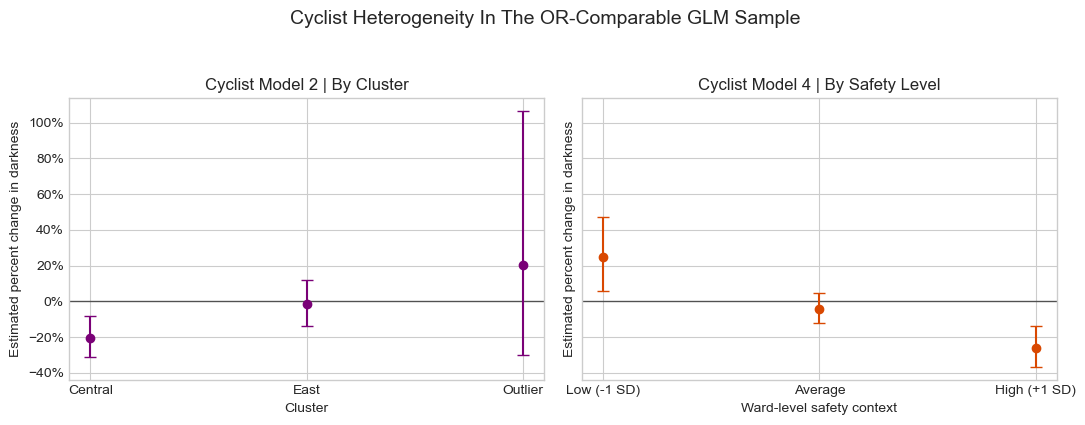

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

ax = axes[0]
cluster_order = ['Central', 'East', 'Outlier']
sub = cyclist_cluster_effects.copy()
sub['x'] = [cluster_order.index(c) for c in sub['cluster']]
ax.axhline(0, color='black', linewidth=1, alpha=0.6)
ax.errorbar(sub['x'], sub['pct'], yerr=[sub['pct'] - sub['lo_pct'], sub['hi_pct'] - sub['pct']], fmt='o', capsize=4, color='#7a0177')
ax.set_xticks(range(len(cluster_order)))
ax.set_xticklabels(cluster_order)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_title('Cyclist Model 2 | By Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Estimated percent change in darkness')

ax = axes[1]
level_order = ['Low (-1 SD)', 'Average', 'High (+1 SD)']
sub = cyclist_safety_effects.copy()
sub['x'] = [level_order.index(v) for v in sub['level']]
ax.axhline(0, color='black', linewidth=1, alpha=0.6)
ax.errorbar(sub['x'], sub['pct'], yerr=[sub['pct'] - sub['lo_pct'], sub['hi_pct'] - sub['pct']], fmt='o', capsize=4, color='#d94801')
ax.set_xticks(range(len(level_order)))
ax.set_xticklabels(level_order)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_title('Cyclist Model 4 | By Safety Level')
ax.set_xlabel('Ward-level safety context')
ax.set_ylabel('Estimated percent change in darkness')

fig.suptitle('Cyclist Heterogeneity In The OR-Comparable GLM Sample', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


### What Figure 3 Means

Figure 3 shows that the cyclist story is mainly a **heterogeneity** story.

- In **Model 2**, the estimated cyclist darkness effect differs sharply by cluster:
  - `Central`: `-20.5%`
  - `East`: `-1.6%`
  - `Outlier`: `+20.4%`
- The raw six-hour panel already points in the same direction:
  - `Central`: `8 of 9` sensors show cyclist drops
  - `East`: `15 of 20` sensors show cyclist drops, but `5` increase
  - `Outlier`: `4 of 8` sensors increase

So the cyclist pooled result is weak **because Bristol does not appear to have one single cyclist darkness response**.

The safety interaction in **Model 4** points in the same direction:
- low safety context: `+24.6%`
- average safety: `-4.1%`
- high safety context: `-26.2%`
- `Dark:safety_z` has `p = 0.000121`

That is a strong model result, but it should be read as a **place-context signal**, not a simple causal claim about safety. The safety measure is ward-level and static, so it is likely capturing broader differences in place type as well.

By contrast, **Model 3** adds very little: CCTV does not meaningfully change the darkness effect in either mode.
- pedestrian `Dark:cctv_z`: `p = 0.948`
- cyclist `Dark:cctv_z`: `p = 0.941`


## What Each GLM Model Finds

The clearest way to read the GLM is model by model, using the **six-hour OR-comparable sample** as the main specification.

### Model 1: Main pooled darkness model

**What it tests**

Model 1 asks the main report question directly: after controlling for regular time structure, weather, lagged counts, and fixed sensor differences, are counts lower in darkness than in daylight?

**Findings**

- **Pedestrians:** about `-33.3%`, `p = 1.48e-09`
- **Cyclists:** about `-4.0%`, `p = 0.446`

**What this means**

This is the main adjusted answer to the question. It strongly supports a substantial pedestrian darkness penalty, but it does not support a strong single city-wide darkness effect for cyclists.

### Model 2: Darkness by cluster

**What it tests**

Model 2 asks whether the darkness effect differs across `Central`, `East`, and `Outlier` sensors.

**Findings for pedestrians**

- Raw six-hour pedestrian drops are very similar across clusters:
  - `Central`: `-45.8%`
  - `East`: `-47.1%`
  - `Outlier`: `-49.7%`
- The GLM also keeps the pedestrian darkness effect negative in every cluster:
  - `Central`: `-32.6%`
  - `East`: `-27.3%`
  - `Outlier`: `-48.3%`
- But the interaction terms are weak:
  - `Dark × East p = 0.711`
  - `Dark × Outlier p = 0.411`

**Findings for cyclists**

- Cluster differences are much larger:
  - `Central`: `-20.5%`
  - `East`: `-1.6%`
  - `Outlier`: `+20.4%`
- `Dark × East` is statistically meaningful with `p = 0.0448`

**What this means**

For walking, Model 2 strengthens the idea that darkness is a broadly similar city-wide barrier. The cluster estimates differ in size, but they all point in the same negative direction and the model does not give strong evidence that pedestrians respond differently by cluster.

For cycling, Model 2 explains why the pooled cyclist effect is weak: the darkness response varies a lot more by place type.

### Model 3: Darkness by CCTV context

**What it tests**

Model 3 asks whether the darkness effect becomes weaker or stronger in places with more nearby CCTV.

**Findings**

- **Pedestrians:** pooled darkness effect stays about `-33.3%`, `p = 7.91e-10`
- **Cyclists:** pooled darkness effect stays about `-3.9%`, `p = 0.448`
- CCTV interaction terms are near zero:
  - pedestrian `p = 0.948`
  - cyclist `p = 0.941`

**What this means**

Model 3 is mainly a negative finding. Nearby CCTV does not explain much of the darkness pattern in these data. The pedestrian effect remains strong without needing CCTV to make sense of it.

### Model 4: Darkness by safety context

**What it tests**

Model 4 asks whether the darkness effect differs across places with different ward-level perceived after-dark safety.

**Findings**

- **Pedestrians:** pooled darkness effect stays about `-34.3%`, `p = 2.01e-09`
- The pedestrian safety interaction is not strong enough to change the main story: `p = 0.160`
- **Cyclists:** the average pooled effect is still weak, but the interaction is strong:
  - low safety: `+24.6%`
  - average safety: `-4.1%`
  - high safety: `-26.2%`
  - `Dark:safety_z p = 0.000121`

**What this means**

For pedestrians, Model 4 again shows that the main darkness result is robust. For cyclists, the fitted darkness effect varies across places with different safety profiles, but this should be interpreted as a broader place-context signal rather than a clean causal safety effect.

### What the nine-hour sensitivity check adds

The expanded nine-hour GLM is useful, but it does not change the main conclusions.

- **Pedestrians:** Model 1 becomes slightly more negative, around `-37.0%`, with `p = 2.57e-10`
- **Cyclists:** Model 1 stays near zero, around `-4.4%`, with `p = 0.395`

So the extra mixed hours confirm that the six-hour story is stable. They do not replace the six-hour GLM as the main analysis.

## Overall Interpretation

Taken together, the methods support three main conclusions.

- **Darkness is a robust barrier to walking in Bristol.** This result appears in the matched OR design, the main six-hour GLM, and the nine-hour sensitivity check.
- **Cycling does not show one uniform city-wide darkness response.** The pooled result is weak, but the cluster and safety models show that the cyclist response varies with place context.
- **Walking and cycling should therefore not be discussed as if they respond to darkness in the same way.** Walking looks broadly and consistently affected. Cycling looks more locally contingent.


## Policy Guidance Backed By The Evidence

The policy implications should follow the strongest supported findings rather than every model output.

1. **Prioritise better lighting on key walking corridors used during commuter-transition hours.**
   The clearest result in the project is the pedestrian darkness penalty: about `-33.3%` in the main six-hour GLM and about `-37.0%` in the nine-hour sensitivity check. ORs are also highest at `05:00` and `06:00`, which points to ordinary utility and commuter walking rather than only late-night travel.

2. **Improve after-dark walking conditions around crossings, bus stops, stations, and access routes to town-centre destinations.**
   The results suggest that darkness matters most when regular trips happen in dark conditions. Practical improvements should therefore focus on visibility, route legibility, crossing clarity, and the perceived continuity of walking routes at the times people travel to work, education, and services.

3. **Plan walking improvements as a network-wide programme rather than a small hotspot scheme.**
   In the six-hour raw panel, `36 of 37` sensors show lower pedestrian counts in darkness, and the raw pedestrian cluster drops are very similar across `Central`, `East`, and `Outlier`. That supports broad corridor-based investment rather than treating the issue as a problem of only one district type.

4. **Use central cycling corridors as the first priority for targeted after-dark cycling intervention.**
   Cycling does not show one uniform city-wide darkness effect, but the central cluster does show a meaningful negative adjusted effect of about `-20.5%`. That makes central commuter corridors the strongest candidate for targeted work on after-dark cycling conditions.

5. **Carry out route-level diagnostics before wider cycling rollout in East and Outlier areas.**
   The cyclist response is mixed outside the central cluster, with East near zero and Outlier positive in the fitted Model 2 estimates. That means the next step should be local diagnosis of route type, trip purpose, junction design, and corridor conditions rather than assuming one intervention will work everywhere.

6. **Evaluate interventions using the same dark-transition hours used in this analysis.**
   The strongest evidence appears in the mixed hours where the same clock time moves between daylight and darkness across the year. Future monitoring should therefore track changes at `5, 6, 17, 18, 19, 20` so the council can measure whether lighting and route-quality interventions reduce the observed darkness penalty.
